# 01/02 - Dataset Understanding & Preparation

This notebook is the only place the raw CIFAR-10 data is explored. The split defined
here is the split used by every experiment in Parts 3-17.

**Rules:** no CNN, no Conv2D, no pretrained models, no
transfer learning. Each `32 x 32 x 3` image is flattened into a `3072`-value
vector and fed to fully connected Dense layers.

## Setup

In [1]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for base in (start, *start.parents):
        if (base / "src" / "config.py").is_file():
            return base
    for child in sorted(c for c in start.iterdir() if c.is_dir()):
        if (child / "src" / "config.py").is_file():
            return child
    raise RuntimeError(
        f"Could not find the project root from {start}.\n"
    )


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import CLASS_NAMES, INPUT_DIM, NUM_CLASSES, SEED
from src.data import load_raw, load_splits
from src.utils import set_seed

set_seed(SEED)
print(f"Seed fixed at {SEED}, every notebook uses it.")

Project root: c:\Users\khali\Downloads\Coding Projects\Deep-Learning-Project-Tuwaiq
Seed fixed at 42, every notebook uses it.


---
# Part 1 - Dataset Understanding

In [2]:
x_train_full, y_train_full, x_test, y_test = load_raw()

print("Training images :", x_train_full.shape)
print("Training labels :", y_train_full.shape)
print("Test images     :", x_test.shape)
print("Test labels     :", y_test.shape)

Training images : (50000, 32, 32, 3)
Training labels : (50000,)
Test images     : (10000, 32, 32, 3)
Test labels     : (10000,)


### Image dimensions, number of classes, and class names

In [3]:
height, width, channels = x_train_full.shape[1:]

print(f"Image dimensions : {height} x {width} x {channels}")
print(f"Flattened length : {height * width * channels} values per image")
print(f"Number of classes: {len(np.unique(y_train_full))}")
print(f"Label dtype      : {y_train_full.dtype}, values {y_train_full.min()}-{y_train_full.max()}")
print()
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

Image dimensions : 32 x 32 x 3
Flattened length : 3072 values per image
Number of classes: 10
Label dtype      : int32, values 0-9

  0: airplane
  1: automobile
  2: bird
  3: cat
  4: deer
  5: dog
  6: frog
  7: horse
  8: ship
  9: truck


### Number of examples in each class

,train,test,train %
airplane,5000,1000,10.0
automobile,5000,1000,10.0
bird,5000,1000,10.0
cat,5000,1000,10.0
deer,5000,1000,10.0
dog,5000,1000,10.0
frog,5000,1000,10.0
horse,5000,1000,10.0
ship,5000,1000,10.0
truck,5000,1000,10.0


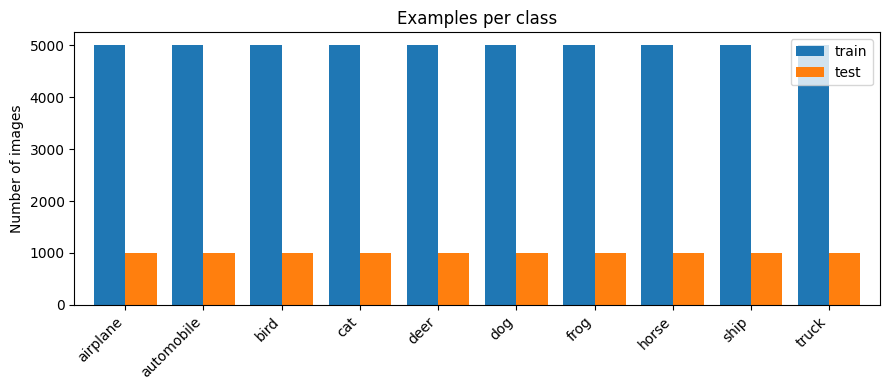

In [4]:
counts = pd.DataFrame(
    {
        "train": np.bincount(y_train_full, minlength=NUM_CLASSES),
        "test": np.bincount(y_test, minlength=NUM_CLASSES),
    },
    index=CLASS_NAMES,
)
counts["train %"] = (100 * counts["train"] / counts["train"].sum()).round(1)
display(counts)

ax = counts[["train", "test"]].plot.bar(figsize=(9, 4), width=0.8)
ax.set_title("Examples per class")
ax.set_ylabel("Number of images")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Findings:** CIFAR-10 is perfectly balanced: 5,000 training and 1,000
test images per class, 10% each. Two consequences matter for the rest of the
project:

1. Accuracy is a fair headline metric here - it cannot be inflated by a
   majority class, the way it could be on an imbalanced dataset.
2. The random-guess baseline is **10%**. Any model we build has to beat that
   comfortably before its learning curves are worth interpreting.

### Pixel-value range

dtype     : uint8
min pixel : 0
max pixel : 255
mean      : 120.71
std       : 64.15


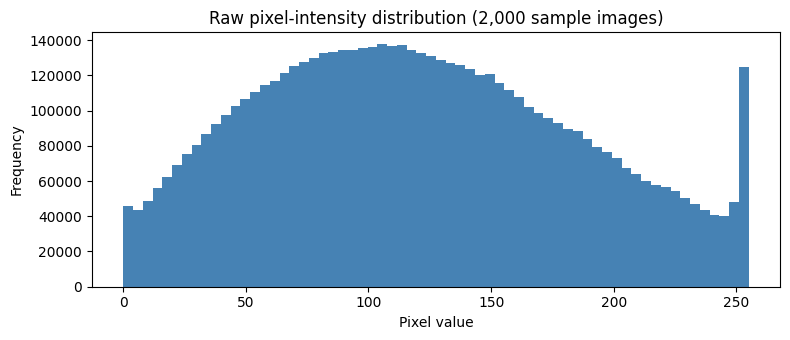

In [5]:
print(f"dtype     : {x_train_full.dtype}")
print(f"min pixel : {x_train_full.min()}")
print(f"max pixel : {x_train_full.max()}")
print(f"mean      : {x_train_full.mean():.2f}")
print(f"std       : {x_train_full.std():.2f}")

plt.figure(figsize=(8, 3.5))
plt.hist(x_train_full[:2000].ravel(), bins=64, color="steelblue")
plt.title("Raw pixel-intensity distribution (2,000 sample images)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

dtype     : float64
min pixel : 0.0
max pixel : 1.0
mean      : 0.47
std       : 0.25


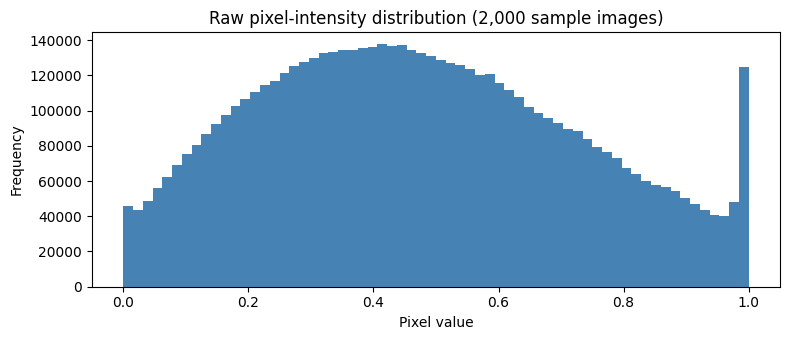

In [6]:
divided = x_train_full / 255.0

print(f"dtype     : {divided.dtype}")
print(f"min pixel : {divided.min()}")
print(f"max pixel : {divided.max()}")
print(f"mean      : {divided.mean():.2f}")
print(f"std       : {divided.std():.2f}")

plt.figure(figsize=(8, 3.5))
plt.hist(divided[:2000].ravel(), bins=64, color="steelblue")
plt.title("Raw pixel-intensity distribution (2,000 sample images)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation.** Pixels are 8-bit unsigned integers spanning the full
0-255 range, with a mean near 121. Feeding values of that magnitude into a
Dense layer produces large activations and large gradients, which makes
training unstable at ordinary learning rates. That is exactly why Part 2
divides by 255.

### Sample images with their labels

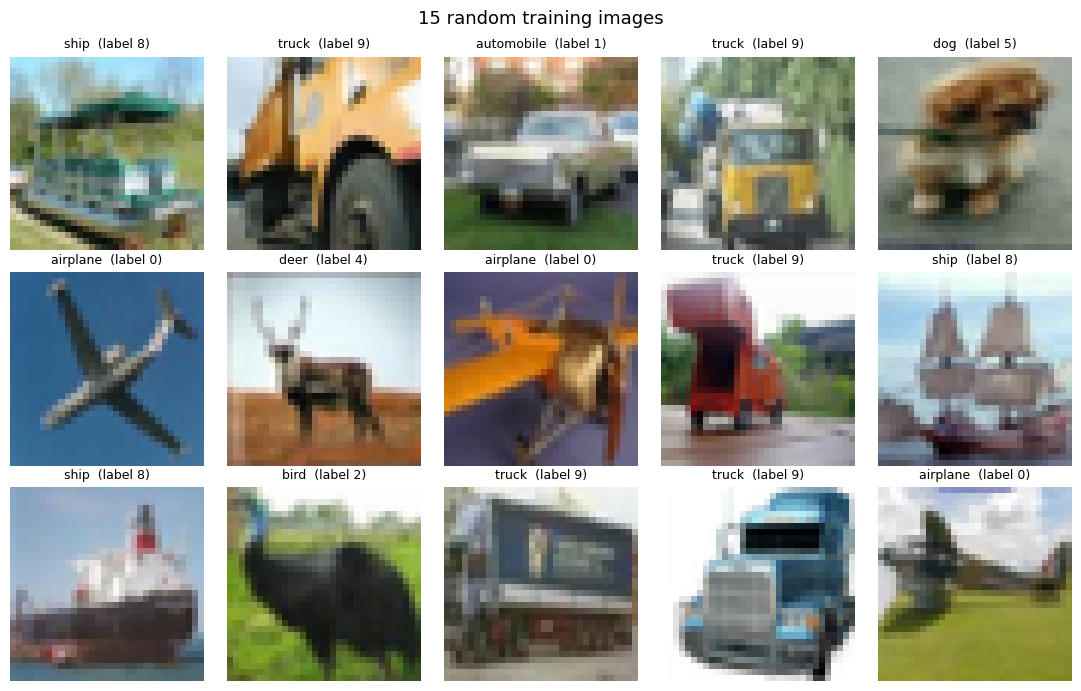

In [7]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_train_full), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(11, 7))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(x_train_full[idx])
    ax.set_title(f"{CLASS_NAMES[y_train_full[idx]]}  (label {y_train_full[idx]})", fontsize=9)
    ax.axis("off")
fig.suptitle("15 random training images", fontsize=13)
plt.tight_layout()
plt.show()

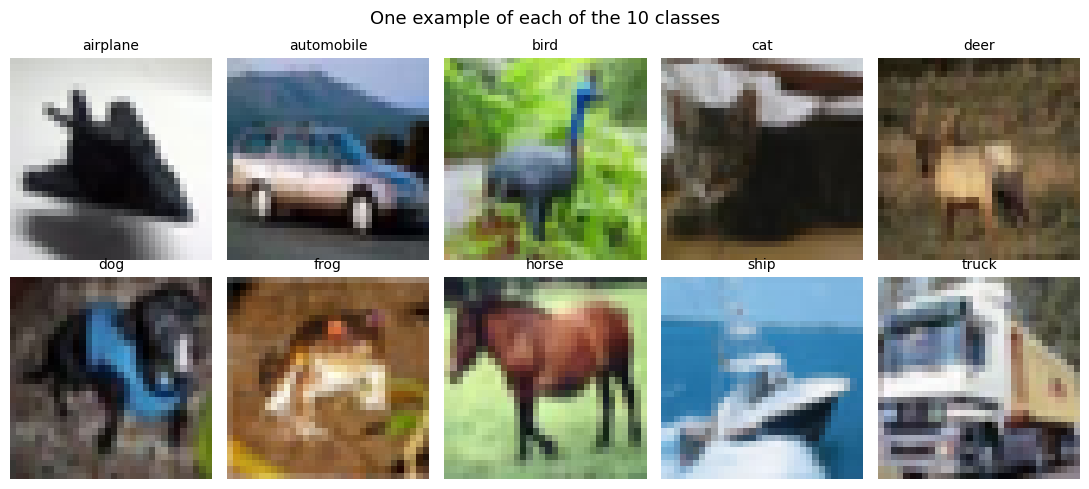

In [8]:
# One image per class, so we can see what the model has to differentiate.
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for label, ax in enumerate(axes.ravel()):
    first = np.flatnonzero(y_train_full == label)[0]
    ax.imshow(x_train_full[first])
    ax.set_title(CLASS_NAMES[label], fontsize=10)
    ax.axis("off")
fig.suptitle("One example of each of the 10 classes", fontsize=13)
plt.tight_layout()
plt.show()

**Findings:** At 32x32 the images are heavily downsampled - object
boundaries are not sharp and the background occupies a large share of every image.
Several classes are visually similar (cat/dog, automobile/truck, deer/horse),

### Part 1 answers

> **What does one sample represent?**
>
> One sample is a single 32x32 colored photograph, stored as a `32 x 32 x 3`
> array of 8-bit pixel intensities: 32 rows, 32 columns, and 3 colour channels
> (red, green, blue). Each sample is paired with one integer label in 0-9
> naming the object shown.

> **What is the target variable?**
>
> The target is the class label `y` - an integer 0-9 identifying which of the
> ten object categories the image belongs to. It is a single categorical
> variable, not ten separate outputs.

> **Is this a binary or multiclass classification problem?**
>
> Multiclass, with 10 different classes. Each image belongs to
> one class, which makes it single-label multiclass classification (not
> multi-label). That is what justifies a softmax output with cross-entropy loss
> rather than sigmoid with binary cross-entropy.

> **What does `32 x 32 x 3` represent?**
>
> Height x width x colour channels: 32 pixel rows, 32 pixel columns, and 3
> channels per pixel. That is `32 * 32 * 3 = 3072` individual intensity values
> per image, which becomes the input dimension of our Dense network once the
> image is flattened.

> **Why does the output layer require 10 neurons?**
>
> Because there are 10 classes and the network must produce one score per
> class. With a softmax activation those 10 outputs form a probability
> distribution that sums to 1, and the prediction is the index of the largest
> value. Fewer neurons could not represent all ten categories; more would
> create outputs with no class to correspond to.

---
# Part 2 - Data Preparation

1. **Normalize pixel values** - divide by 255 so inputs land in `[0, 1]`.

2. **Convert images into vectors** - each `(32, 32, 3)` image becomes a
   `(3072,)` vector. We do this with a `Flatten()` layer as the first layer
   of every model rather than reshaping the arrays here, so the conversion
   is visible in `model.summary()`.
3. **Create three separate sets** - train / validation / test, and use the
   *same* split for the entire project.

The test set stays sealed until Part 16. The validation set is carved out of
the training half only, so nothing from the test set can influence any
architecture or hyperparameter decision.

In [9]:
data = load_splits()   # (N, 32, 32, 3), pixels scaled to [0, 1]
print(data.summary())

X_train  (45000, 32, 32, 3)  float32
X_val    (5000, 32, 32, 3)   float32
X_test   (10000, 32, 32, 3)  float32
y_train  (45000,)            int32
y_val    (5000,)             int32
y_test   (10000,)            int32


### Verifying the preparation did what we claim

In [10]:
# 1. Normalization
print(f"X_train range : {data.X_train.min():.3f} - {data.X_train.max():.3f}  (dtype {data.X_train.dtype})")
print(f"X_train mean  : {data.X_train.mean():.3f}")

# 2. Vector shape
# shape[1:] not shape[1]: this stays correct whether load_splits() returned
# (N, 3072) or (N, 32, 32, 3).
per_sample = data.X_train.shape[1:]
n_values = int(np.prod(per_sample))
print(f"\nPer-sample shape : {per_sample}")
print(f"Values per image : {n_values} (expected {INPUT_DIM})")

# 3. Split sizes add up
total = len(data.X_train) + len(data.X_val)
print(f"\ntrain + val   : {len(data.X_train):,} + {len(data.X_val):,} = {total:,} (the original 50,000)")
print(f"test held out : {len(data.X_test):,}")

# 4. The validation set is stratified: 500 of each class
val_counts = np.bincount(data.y_val, minlength=NUM_CLASSES)
print(f"\nValidation examples per class: {val_counts}")
print(f"Balanced: {len(set(val_counts)) == 1}")

X_train range : 0.000 - 1.000  (dtype float32)
X_train mean  : 0.473

Per-sample shape : (32, 32, 3)
Values per image : 3072 (expected 3072)

train + val   : 45,000 + 5,000 = 50,000 (the original 50,000)
test held out : 10,000

Validation examples per class: [500 500 500 500 500 500 500 500 500 500]
Balanced: True


In [11]:
split_check = pd.DataFrame(
    {
        "train": np.bincount(data.y_train, minlength=NUM_CLASSES),
        "val": np.bincount(data.y_val, minlength=NUM_CLASSES),
        "test": np.bincount(data.y_test, minlength=NUM_CLASSES),
    },
    index=CLASS_NAMES,
)
display(split_check)

,train,val,test
airplane,4500,500,1000
automobile,4500,500,1000
bird,4500,500,1000
cat,4500,500,1000
deer,4500,500,1000
dog,4500,500,1000
frog,4500,500,1000
horse,4500,500,1000
ship,4500,500,1000
truck,4500,500,1000


### Final shapes

| Array | Shape | After `Flatten()` | Meaning |
|---|---|---|---|
| `X_train` | `(45000, 32, 32, 3)` | `(45000, 3072)` | normalized training images |
| `X_val`   | `(5000, 32, 32, 3)`  | `(5000, 3072)`  | held out for model selection |
| `X_test`  | `(10000, 32, 32, 3)` | `(10000, 3072)` | sealed until Part 16 |
| `y_train` | `(45000,)`           | -               | integer labels 0-9 |
| `y_val`   | `(5000,)`            | -               | integer labels 0-9 |
| `y_test`  | `(10000,)`           | -               | integer labels 0-9 |

Each image is stored in its natural `32 x 32 x 3` form and converted to a
`3072`-value vector by the `Flatten()` layer at the top of every model.

**Why these choices:**

- **Divide by 255:** keeps the inputs between `[0, 1]`,
  non-negative and interpretable.
- **10% validation (5,000 images):** Large enough that validation accuracy
  moves in meaningful steps.
- **Stratified:** Every class contributes exactly 500 validation images, so
  validation accuracy is not skewed by an over-represented class.
- **Integer labels, not one-hot:** We pair these with
  `sparse_categorical_crossentropy`, however `src.data.to_onehot()` is available if we
  ever want `categorical_crossentropy` instead but the two are
  mathematically identical.